# RAG Değerlendirme Raporu
#
Bu notebook, `tests/rag_eval_qa_200.json` içindeki 200 adet soru-cevap kaydını kullanarak RAG sisteminin metriklerini (Recall@5, MRR, EM, F1, semantik benzerlik, groundedness, halüsinasyon oranı ve p95 gecikme) sırayla hesaplamak için hazırlanmıştır. Her adımda kullanılan veri ve yöntemleri kayıt altına alınacaktır.

In [1]:
from pathlib import Path
import json
import pandas as pd

NOTEBOOK_DIR = Path(__file__).parent if '__file__' in globals() else Path.cwd()
DATA_PATH = NOTEBOOK_DIR / 'rag_eval_qa_200.json'
if not DATA_PATH.exists():
    DATA_PATH = NOTEBOOK_DIR.parent / 'tests' / 'rag_eval_qa_200.json'
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Veri dosyası bulunamadı: {DATA_PATH}')

with DATA_PATH.open(encoding='utf-8') as f:
    qa_data = json.load(f)

df = pd.DataFrame(qa_data)
df.head()

,id,question,answer,source
0,law_001,2547 sayılı Yükseköğretim Kanunu Madde 1'e gör...,Bu kanunun amacı; yükseköğretimle ilgili amaç ...,"{'doc': 'yuksek_ogretim_kanunu', 'madde': 1}"
1,law_002,2547 sayılı Yükseköğretim Kanunu Madde 2'e gör...,"Bu kanun; yükseköğretim üst kuruluşlarını, büt...","{'doc': 'yuksek_ogretim_kanunu', 'madde': 2}"
2,law_003,2547 sayılı Yükseköğretim Kanunu Madde 3'e gör...,(Değişik: 17/8/1983 - 2880/1 md.) Bu Kanunda g...,"{'doc': 'yuksek_ogretim_kanunu', 'madde': 3}"
3,law_004,2547 sayılı Yükseköğretim Kanunu Madde 4'e gör...,Yükseköğretimin amacı: a) Öğrencilerini; (1) A...,"{'doc': 'yuksek_ogretim_kanunu', 'madde': 4}"
4,law_005,2547 sayılı Yükseköğretim Kanunu Madde 5'e gör...,"Yükseköğretim, aşağıdaki ""Ana ilkeler"" doğrult...","{'doc': 'yuksek_ogretim_kanunu', 'madde': 5}"


In [2]:
df = df.assign(
    source_doc=df['source'].apply(lambda x: x['doc']),
    source_article=df['source'].apply(lambda x: x['madde']),
)

doc_counts = (
    df['source_doc'].value_counts()
    .rename_axis('source_doc')
    .reset_index(name='question_count')
)
doc_counts

,source_doc,question_count
0,yuksek_ogretim_kanunu,146
1,BUU_yuksek_ogretim_yonetmeligi,54


In [3]:
DOC_ID_ALIASES = {
    'buu_yuksek_ogretim_yonetmeligi': 'buu_yonetmelik',
    'buu_yonetmelik': 'buu_yonetmelik',
    'yuksek_ogretim_kanunu': 'yuksek_ogretim_kanunu',
}

def normalize_doc_id(value: str | None) -> str | None:
    if not isinstance(value, str):
        return value
    key = value.strip().lower()
    return DOC_ID_ALIASES.get(key, key)

df['source_doc_norm'] = df['source_doc'].map(normalize_doc_id)
df[['source_doc', 'source_doc_norm', 'source_article']].head()

,source_doc,source_doc_norm,source_article
0,yuksek_ogretim_kanunu,yuksek_ogretim_kanunu,1
1,yuksek_ogretim_kanunu,yuksek_ogretim_kanunu,2
2,yuksek_ogretim_kanunu,yuksek_ogretim_kanunu,3
3,yuksek_ogretim_kanunu,yuksek_ogretim_kanunu,4
4,yuksek_ogretim_kanunu,yuksek_ogretim_kanunu,5


In [4]:
import sys

PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'src').exists() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('c:/Users/emirh/Desktop/buu_llm_rag')

In [5]:
from tqdm.auto import tqdm

import importlib
import src.config as config_module

config_module = importlib.reload(config_module)

EMBEDDING_MODEL_NAME = config_module.EMBEDDING_MODEL_NAME
EMBEDDING_BACKEND = getattr(config_module, 'EMBEDDING_BACKEND', 'openai')
FAISS_INDEX_PATH = config_module.FAISS_INDEX_PATH
METADATA_PATH = config_module.METADATA_PATH
DEFAULT_TOP_K = config_module.DEFAULT_TOP_K

from src.embeddings.providers import create_embedding_client
from src.retriever.faiss_index import (
    load_faiss_index,
    load_metadata,
    search_index,
    get_top_k_results,
)

embedding_client = create_embedding_client(
    backend=EMBEDDING_BACKEND,
    model_name=EMBEDDING_MODEL_NAME,
)
faiss_index = load_faiss_index(FAISS_INDEX_PATH)
metadata = load_metadata(METADATA_PATH)

len(metadata)

291

In [6]:
import numpy as np

def normalize_article_label(value):
    if value is None:
        return None
    value_str = str(value).strip()
    digits = ''.join(ch for ch in value_str if ch.isdigit())
    return digits or value_str.lower()

metadata_doc_ids = [normalize_doc_id(entry.get('doc_id')) for entry in metadata]
metadata_article_norm = [normalize_article_label(entry.get('article_no')) for entry in metadata]

def build_gold_span_id(doc_id: str | None, article: str | None) -> str:
    doc_part = doc_id or 'unknown_doc'
    article_part = article or 'unknown_article'
    return f"{doc_part}::madde::{article_part}"

df['source_article_norm'] = df['source_article'].apply(normalize_article_label)
df['gold_span_id'] = df.apply(lambda row: build_gold_span_id(row['source_doc_norm'], row['source_article_norm']), axis=1)
df[['source_doc_norm', 'source_article', 'source_article_norm', 'gold_span_id']].head()

,source_doc_norm,source_article,source_article_norm,gold_span_id
0,yuksek_ogretim_kanunu,1,1,yuksek_ogretim_kanunu::madde::1
1,yuksek_ogretim_kanunu,2,2,yuksek_ogretim_kanunu::madde::2
2,yuksek_ogretim_kanunu,3,3,yuksek_ogretim_kanunu::madde::3
3,yuksek_ogretim_kanunu,4,4,yuksek_ogretim_kanunu::madde::4
4,yuksek_ogretim_kanunu,5,5,yuksek_ogretim_kanunu::madde::5


## Recall@5 ve MRR hesaplaması
Önce tüm soruların embeddinglerini hesaplayıp FAISS üzerinden arama yapacağız; ardından doğruluk metriklerini raporlayacağız.

In [7]:
from typing import List, Tuple


def embed_queries(texts: List[str], batch_size: int = 32) -> np.ndarray:
    return embedding_client.embed(
        texts,
        batch_size=batch_size,
        show_progress=True,
    )


def evaluate_recall_mrr(dataset: pd.DataFrame, top_k: int = DEFAULT_TOP_K, batch_size: int = 32) -> Tuple[dict, pd.DataFrame]:
    queries = dataset['question'].tolist()
    query_embeddings = embed_queries(queries, batch_size=batch_size)
    distances, indices = search_index(faiss_index, query_embeddings, top_k=top_k)

    hits = []
    reciprocal_ranks = []
    per_query_rows = []

    for row_idx, idx_row in enumerate(indices):
        target_doc = dataset.at[row_idx, 'source_doc_norm']
        target_article = dataset.at[row_idx, 'source_article_norm']
        gold_span_id = dataset.at[row_idx, 'gold_span_id']
        original_doc = dataset.at[row_idx, 'source_doc']
        original_article = dataset.at[row_idx, 'source_article']
        relevant_rank = None
        for rank, idx in enumerate(idx_row):
            if idx < 0:
                continue
            if metadata_doc_ids[idx] == target_doc and metadata_article_norm[idx] == target_article:
                relevant_rank = rank
                break
        hits.append(1 if relevant_rank is not None else 0)
        reciprocal_ranks.append(1.0 / (relevant_rank + 1) if relevant_rank is not None else 0.0)
        per_query_rows.append({
            'id': dataset.at[row_idx, 'id'],
            'question': dataset.at[row_idx, 'question'],
            'original_doc': original_doc,
            'original_article': original_article,
            'target_doc': target_doc,
            'target_article': target_article,
            'gold_span_id': gold_span_id,
            'relevant_rank': None if relevant_rank is None else relevant_rank + 1,
            'hit': relevant_rank is not None,
        })

    metrics = {
        'top_k': top_k,
        'recall_at_k': float(np.mean(hits)) if hits else 0.0,
        'mrr': float(np.mean(reciprocal_ranks)) if reciprocal_ranks else 0.0,
    }
    details_df = pd.DataFrame(per_query_rows)
    return metrics, details_df

In [8]:
retrieval_metrics, retrieval_details = evaluate_recall_mrr(df, top_k=DEFAULT_TOP_K, batch_size=32)
retrieval_metrics

Embedding (OpenAI):   0%|          | 0/7 [00:00<?, ?it/s]

{'top_k': 5, 'recall_at_k': 0.895, 'mrr': 0.7094166666666666}

In [9]:
rank_summary = retrieval_details['relevant_rank'].fillna('miss').value_counts()
rank_summary = rank_summary.reindex(['miss', 1, 2, 3, 4, 5], fill_value=0)
rank_summary

relevant_rank
miss     21
1       119
2        22
3        31
4         3
5         4
Name: count, dtype: int64

In [10]:
retrieval_details.head()

,id,question,original_doc,original_article,target_doc,target_article,gold_span_id,relevant_rank,hit
0,law_001,2547 sayılı Yükseköğretim Kanunu Madde 1'e gör...,yuksek_ogretim_kanunu,1,yuksek_ogretim_kanunu,1,yuksek_ogretim_kanunu::madde::1,1.0,True
1,law_002,2547 sayılı Yükseköğretim Kanunu Madde 2'e gör...,yuksek_ogretim_kanunu,2,yuksek_ogretim_kanunu,2,yuksek_ogretim_kanunu::madde::2,1.0,True
2,law_003,2547 sayılı Yükseköğretim Kanunu Madde 3'e gör...,yuksek_ogretim_kanunu,3,yuksek_ogretim_kanunu,3,yuksek_ogretim_kanunu::madde::3,3.0,True
3,law_004,2547 sayılı Yükseköğretim Kanunu Madde 4'e gör...,yuksek_ogretim_kanunu,4,yuksek_ogretim_kanunu,4,yuksek_ogretim_kanunu::madde::4,1.0,True
4,law_005,2547 sayılı Yükseköğretim Kanunu Madde 5'e gör...,yuksek_ogretim_kanunu,5,yuksek_ogretim_kanunu,5,yuksek_ogretim_kanunu::madde::5,1.0,True


### Kanun tarafı hatalarının analizi
Kaçan örneklerin top-k sonuçlarını inceleyerek hata türlerini kategorize ediyoruz.

In [11]:
def inspect_doc_failures(doc_id: str, num_samples: int = 5, top_k: int = DEFAULT_TOP_K) -> pd.DataFrame:
    merged = df.merge(retrieval_details[['id', 'hit', 'relevant_rank']], on='id', how='left')
    failure_rows = merged[(merged['source_doc_norm'] == doc_id) & (~merged['hit'].fillna(False))]
    if failure_rows.empty:
        return pd.DataFrame()
    sample_rows = failure_rows.sample(n=min(num_samples, len(failure_rows)), random_state=42)
    rows = []
    for _, row in sample_rows.iterrows():
        query_embedding = embedding_client.embed_one(row['question'])
        distances, indices = search_index(faiss_index, query_embedding, top_k=top_k)
        for rank, (score, idx) in enumerate(zip(distances[0], indices[0]), start=1):
            if idx < 0:
                continue
            meta = metadata[idx]
            meta_doc_norm = normalize_doc_id(meta.get('doc_id'))
            rows.append({
                'id': row['id'],
                'question': row['question'][:160] + '...',
                'expected_doc': row['source_doc_norm'],
                'expected_article': row['source_article'],
                'retrieved_doc': meta_doc_norm,
                'retrieved_article': meta.get('article_no'),
                'score': float(score),
                'rank': rank,
                'doc_match': meta_doc_norm == row['source_doc_norm'],
            })
    return pd.DataFrame(rows)

In [12]:
kanun_failures = inspect_doc_failures('yuksek_ogretim_kanunu', num_samples=5, top_k=DEFAULT_TOP_K)
kanun_failures.head(20)

,id,question,expected_doc,expected_article,retrieved_doc,retrieved_article,score,rank,doc_match
0,law_030,2547 sayılı Yükseköğretim Kanunu Madde 30'e gö...,yuksek_ogretim_kanunu,30,yuksek_ogretim_kanunu,MADDE 39,0.639265,1,True
1,law_030,2547 sayılı Yükseköğretim Kanunu Madde 30'e gö...,yuksek_ogretim_kanunu,30,yuksek_ogretim_kanunu,MADDE 65,0.635750,2,True
2,law_030,2547 sayılı Yükseköğretim Kanunu Madde 30'e gö...,yuksek_ogretim_kanunu,30,yuksek_ogretim_kanunu,MADDE 31,0.610984,3,True
3,law_030,2547 sayılı Yükseköğretim Kanunu Madde 30'e gö...,yuksek_ogretim_kanunu,30,yuksek_ogretim_kanunu,MADDE 77,0.610917,4,True
4,law_030,2547 sayılı Yükseköğretim Kanunu Madde 30'e gö...,yuksek_ogretim_kanunu,30,yuksek_ogretim_kanunu,MADDE 35,0.609736,5,True
5,law_021,2547 sayılı Yükseköğretim Kanunu Madde 21'e gö...,yuksek_ogretim_kanunu,21,yuksek_ogretim_kanunu,MADDE 21,0.617505,1,True
6,law_021,2547 sayılı Yükseköğretim Kanunu Madde 21'e gö...,yuksek_ogretim_kanunu,21,yuksek_ogretim_kanunu,MADDE 43,0.606956,2,True
7,law_021,2547 sayılı Yükseköğretim Kanunu Madde 21'e gö...,yuksek_ogretim_kanunu,21,yuksek_ogretim_kanunu,MADDE 65,0.545266,3,True
8,law_021,2547 sayılı Yükseköğretim Kanunu Madde 21'e gö...,yuksek_ogretim_kanunu,21,yuksek_ogretim_kanunu,MADDE 8,0.543182,4,True
9,law_021,2547 sayılı Yükseköğretim Kanunu Madde 21'e gö...,yuksek_ogretim_kanunu,21,buu_yonetmelik,MADDE 3,0.536713,5,False


In [13]:
kanun_failures.loc[:, ['id', 'expected_article', 'retrieved_doc', 'retrieved_article', 'rank', 'score', 'doc_match']].head(10)

,id,expected_article,retrieved_doc,retrieved_article,rank,score,doc_match
0,law_030,30,yuksek_ogretim_kanunu,MADDE 39,1,0.639265,True
1,law_030,30,yuksek_ogretim_kanunu,MADDE 65,2,0.635750,True
2,law_030,30,yuksek_ogretim_kanunu,MADDE 31,3,0.610984,True
3,law_030,30,yuksek_ogretim_kanunu,MADDE 77,4,0.610917,True
4,law_030,30,yuksek_ogretim_kanunu,MADDE 35,5,0.609736,True
5,law_021,21,yuksek_ogretim_kanunu,MADDE 21,1,0.617505,True
6,law_021,21,yuksek_ogretim_kanunu,MADDE 43,2,0.606956,True
7,law_021,21,yuksek_ogretim_kanunu,MADDE 65,3,0.545266,True
8,law_021,21,yuksek_ogretim_kanunu,MADDE 8,4,0.543182,True
9,law_021,21,buu_yonetmelik,MADDE 3,5,0.536713,False


In [14]:
summary_cols = kanun_failures.loc[:, ['id', 'expected_article', 'retrieved_article', 'rank', 'score', 'doc_match']].copy()
summary_cols['score'] = summary_cols['score'].round(3)
summary_cols.head(10).to_markdown(index=False)

'| id      |   expected_article | retrieved_article   |   rank |   score | doc_match   |\n|:--------|-------------------:|:--------------------|-------:|--------:|:------------|\n| law_030 |                 30 | MADDE 39            |      1 |   0.639 | True        |\n| law_030 |                 30 | MADDE 65            |      2 |   0.636 | True        |\n| law_030 |                 30 | MADDE 31            |      3 |   0.611 | True        |\n| law_030 |                 30 | MADDE 77            |      4 |   0.611 | True        |\n| law_030 |                 30 | MADDE 35            |      5 |   0.61  | True        |\n| law_021 |                 21 | MADDE 21            |      1 |   0.618 | True        |\n| law_021 |                 21 | MADDE 43            |      2 |   0.607 | True        |\n| law_021 |                 21 | MADDE 65            |      3 |   0.545 | True        |\n| law_021 |                 21 | MADDE 8             |      4 |   0.543 | True        |\n| law_021 |         

In [15]:
kanun_analysis = kanun_failures.assign(
    expected_article_norm=lambda d: d['expected_article'].apply(normalize_article_label),
    retrieved_article_norm=lambda d: d['retrieved_article'].apply(normalize_article_label),
)
kanun_doc_summary = (
    kanun_analysis.groupby(['doc_match', 'expected_article_norm', 'retrieved_article_norm'], dropna=False)
    .agg(sample_count=('id', 'count'))
    .sort_values('sample_count', ascending=False)
    .head(20)
)
kanun_doc_summary

sample_count
doc_match expected_article_norm retrieved_article_norm              
False     32                    12                                 2
                                3                                  2
True      32                    65                                 2
                                43                                 2
                                35                                 2
False     21                    3                                  1
True      21                    21                                 1
                                43                                 1
          30                    35                                 1
          21                    65                                 1
                                8                                  1
          30                    31                                 1
                                77                                 1
                                65                                 1
                                39                                 1
          53                    12                                 1
                                51                                 1
                                52                                 1
                                57                                 1
                                65                                 1

In [16]:
metadata_df = pd.DataFrame(metadata).assign(
    doc_id=lambda d: d['doc_id'].apply(normalize_doc_id),
    article_norm=lambda d: d['article_no'].apply(normalize_article_label),
)
kanun_metadata = metadata_df[metadata_df['doc_id'] == 'yuksek_ogretim_kanunu']
kanun_metadata.head()


,id,doc_id,doc_type,doc_name,article_no,paragraph_no,section_title,text,article_norm
0,yuksek_ogretim_kanunu_madde1,yuksek_ogretim_kanunu,kanun,2547 Sayılı Yükseköğretim Kanunu,MADDE 1,None,None,MADDE 1\n\nMadde 1 – Bu kanunun amacı; yüksekö...,1
1,yuksek_ogretim_kanunu_madde2,yuksek_ogretim_kanunu,kanun,2547 Sayılı Yükseköğretim Kanunu,MADDE 2,None,None,MADDE 2\n\nMadde 2 – Bu kanun; yükseköğretim ü...,2
2,yuksek_ogretim_kanunu_madde3,yuksek_ogretim_kanunu,kanun,2547 Sayılı Yükseköğretim Kanunu,MADDE 3,None,İKİNCİ BÖLÜM,MADDE 3 | İKİNCİ BÖLÜM\n\nMadde 3 – (Değişik: ...,3
3,yuksek_ogretim_kanunu_madde4,yuksek_ogretim_kanunu,kanun,2547 Sayılı Yükseköğretim Kanunu,MADDE 4,None,None,MADDE 4\n\nMadde 4 – Yükseköğretimin amacı:\na...,4
4,yuksek_ogretim_kanunu_madde5,yuksek_ogretim_kanunu,kanun,2547 Sayılı Yükseköğretim Kanunu,MADDE 5,None,Üst Kuruluşlar,MADDE 5 | Üst Kuruluşlar\n\nMadde 5 – Yükseköğ...,5


In [17]:
kanun_mismatches = kanun_analysis[(kanun_analysis['doc_match']) & (kanun_analysis['expected_article_norm'] != kanun_analysis['retrieved_article_norm'])].copy()
expected_problem_articles = sorted(kanun_mismatches['expected_article_norm'].dropna().unique())
retrieved_problem_articles = sorted(kanun_mismatches['retrieved_article_norm'].dropna().unique())
metadata_expected = kanun_metadata[kanun_metadata['article_norm'].isin(expected_problem_articles)]
metadata_retrieved = kanun_metadata[kanun_metadata['article_norm'].isin(retrieved_problem_articles)]

columns_to_show = [col for col in ['article_no', 'article_norm', 'article_title'] if col in kanun_metadata.columns]
if not columns_to_show:
    raise KeyError("kanun_metadata içinde gösterilecek sütun bulunamadı; metadata yapısını kontrol et")

metadata_expected[columns_to_show].head(20)
metadata_retrieved[columns_to_show].head(20)

,article_no,article_norm
7,MADDE 8,8
11,MADDE 12,12
30,MADDE 31,31
34,MADDE 35,35
38,MADDE 39,39
42,MADDE 43,43
50,MADDE 51,51
51,MADDE 52,52
56,MADDE 57,57
64,MADDE 65,65


In [18]:
import random


def inspect_buu_failures(num_samples: int = 3, top_k: int = DEFAULT_TOP_K) -> pd.DataFrame:
    merged = df.merge(retrieval_details[['id', 'hit']], on='id', how='left')
    buu_mask = merged['source_doc_norm'] != 'yuksek_ogretim_kanunu'
    failure_rows = merged[buu_mask & (~merged['hit'].fillna(False))]
    if failure_rows.empty:
        return pd.DataFrame()
    sample_rows = failure_rows.sample(n=min(num_samples, len(failure_rows)), random_state=42)
    records = []
    for _, row in sample_rows.iterrows():
        query_embedding = embedding_client.embed_one(row['question'])
        distances, indices = search_index(faiss_index, query_embedding, top_k=top_k)
        for rank, (score, idx) in enumerate(zip(distances[0], indices[0]), start=1):
            if idx < 0:
                continue
            meta = metadata[idx]
            meta_doc_norm = normalize_doc_id(meta.get('doc_id'))
            records.append({
                'id': row['id'],
                'question': row['question'][:120] + '...',
                'expected_doc': row['source_doc_norm'],
                'retrieved_doc': meta_doc_norm,
                'retrieved_article': meta.get('article_no'),
                'score': float(score),
                'rank': rank,
                'doc_match': meta_doc_norm == row['source_doc_norm'],
            })
    return pd.DataFrame(records)


buu_debug = inspect_buu_failures(num_samples=3, top_k=DEFAULT_TOP_K)
buu_debug.head(15)

""


## EM / F1 değerlendirmesi için hazırlık

In [9]:
import re
import string

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def compute_em(prediction: str, reference: str) -> float:
    return 1.0 if normalize_text(prediction) == normalize_text(reference) and reference else 0.0

def compute_f1(prediction: str, reference: str) -> float:
    pred_tokens = normalize_text(prediction).split()
    ref_tokens = normalize_text(reference).split()
    if not pred_tokens or not ref_tokens:
        return 1.0 if pred_tokens == ref_tokens else 0.0
    common = set(pred_tokens) & set(ref_tokens)
    if not common:
        return 0.0
    precision = sum(token in ref_tokens for token in pred_tokens) / len(pred_tokens)
    recall = sum(token in pred_tokens for token in ref_tokens) / len(ref_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

In [10]:
def prepare_eval_examples(dataset: pd.DataFrame, top_k: int = DEFAULT_TOP_K, batch_size: int = 32) -> List[dict]:
    queries = dataset['question'].tolist()
    query_embeddings = embed_queries(queries, batch_size=batch_size)
    distances, indices = search_index(faiss_index, query_embeddings, top_k=top_k)
    topk_results = get_top_k_results(distances, indices, metadata, top_k=top_k)
    examples = []
    for row, ctx in zip(dataset.itertuples(index=False), topk_results):
        contexts = []
        for item in ctx:
            meta = item['metadata']
            context_header = f"{meta.get('doc_name', meta.get('doc_id'))} | {meta.get('article_no')}"
            contexts.append(f"{context_header}\n{meta.get('text', '')}")
        examples.append({
            'id': row.id,
            'question': row.question,
            'reference_answer': row.answer,
            'contexts': contexts,
        })
    return examples

eval_examples = prepare_eval_examples(df, top_k=DEFAULT_TOP_K, batch_size=32)
len(eval_examples)

Embedding (OpenAI):   0%|          | 0/7 [00:00<?, ?it/s]

200

In [11]:
def mock_answer_generator(examples: List[dict]) -> pd.DataFrame:
    rows = []
    for item in examples:
        candidate = item['contexts'][0] if item['contexts'] else ''
        rows.append({
            'id': item['id'],
            'question': item['question'],
            'reference_answer': item['reference_answer'],
            'prediction': candidate[:500],
        })
    return pd.DataFrame(rows)

mock_predictions = mock_answer_generator(eval_examples)
mock_predictions.head()

,id,question,reference_answer,prediction
0,law_001,2547 sayılı Yükseköğretim Kanunu Madde 1'e gör...,Bu kanunun amacı; yükseköğretimle ilgili amaç ...,2547 Sayılı Yükseköğretim Kanunu | MADDE 1\nMA...
1,law_002,2547 sayılı Yükseköğretim Kanunu Madde 2'e gör...,"Bu kanun; yükseköğretim üst kuruluşlarını, büt...",2547 Sayılı Yükseköğretim Kanunu | MADDE 2\nMA...
2,law_003,2547 sayılı Yükseköğretim Kanunu Madde 3'e gör...,(Değişik: 17/8/1983 - 2880/1 md.) Bu Kanunda g...,Bursa Uluda? ?niversitesi Lisans?st? E?itim-??...
3,law_004,2547 sayılı Yükseköğretim Kanunu Madde 4'e gör...,Yükseköğretimin amacı: a) Öğrencilerini; (1) A...,2547 Sayılı Yükseköğretim Kanunu | MADDE 4\nMA...
4,law_005,2547 sayılı Yükseköğretim Kanunu Madde 5'e gör...,"Yükseköğretim, aşağıdaki ""Ana ilkeler"" doğrult...",2547 Sayılı Yükseköğretim Kanunu | MADDE 5\nMA...


In [12]:
def score_predictions(predictions: pd.DataFrame) -> Tuple[dict, pd.DataFrame]:
    scored = predictions.assign(
        em=lambda d: d.apply(lambda row: compute_em(row['prediction'], row['reference_answer']), axis=1),
        f1=lambda d: d.apply(lambda row: compute_f1(row['prediction'], row['reference_answer']), axis=1),
    )
    metrics = {
        'exact_match': float(scored['em'].mean()),
        'f1': float(scored['f1'].mean()),
        'sample_size': len(scored),
    }
    return metrics, scored

mock_metrics, scored_predictions = score_predictions(mock_predictions)
mock_metrics

{'exact_match': 0.0, 'f1': 0.47250884024746626, 'sample_size': 200}

## Gerçek LLM Çıktısı ile F1 Hesaplama
Aşağıdaki kod, GPT-4.1-mini modelini kullanarak gerçek yanıtlar üretir ve F1 skorunu hesaplar.
**Not:** Bu işlem API maliyeti gerektirir ve ~10-15 dakika sürebilir.

In [16]:
# Gerçek F1 Hesaplama (LLM ile)
# Bu hücreyi çalıştırmak API maliyeti gerektirir!

from src.rag.pipeline import RAGPipeline

def real_answer_generator(examples: List[dict], sample_size: int = None) -> pd.DataFrame:
    """Gerçek LLM çıktısı ile prediction üretir."""
    pipeline = RAGPipeline()
    
    # Örneklem boyutunu sınırla (maliyet kontrolü için)
    if sample_size:
        examples = examples[:sample_size]
    
    rows = []
    for item in tqdm(examples, desc="LLM Yanıt Üretimi"):
        try:
            # pipeline.answer() metodunu kullan
            prediction = pipeline.answer(item['question'])
        except Exception as e:
            prediction = f"HATA: {e}"
        
        rows.append({
            'id': item['id'],
            'question': item['question'],
            'reference_answer': item['reference_answer'],
            'prediction': prediction,
        })
    
    return pd.DataFrame(rows)

# Önce 10 örnek ile test (maliyet kontrolü için)
real_predictions = real_answer_generator(eval_examples, sample_size=10)
real_metrics, real_scored = score_predictions(real_predictions)
print("Gerçek LLM F1 Sonuçları (10 örnek):", real_metrics)

LLM Yanıt Üretimi:   0%|          | 0/10 [00:00<?, ?it/s]

Gerçek LLM F1 Sonuçları (10 örnek): {'exact_match': 0.0, 'f1': 0.4259822307580853, 'sample_size': 10}


In [17]:
# Sonuçları incele
real_scored[['question', 'reference_answer', 'prediction', 'f1']].head(10)

,question,reference_answer,prediction,f1
0,2547 sayılı Yükseköğretim Kanunu Madde 1'e gör...,Bu kanunun amacı; yükseköğretimle ilgili amaç ...,YANIT: \n2547 sayılı Yükseköğretim Kanunu Mad...,0.680358
1,2547 sayılı Yükseköğretim Kanunu Madde 2'e gör...,"Bu kanun; yükseköğretim üst kuruluşlarını, büt...",YANIT:\n2547 sayılı Yükseköğretim Kanunu Madde...,0.552995
2,2547 sayılı Yükseköğretim Kanunu Madde 3'e gör...,(Değişik: 17/8/1983 - 2880/1 md.) Bu Kanunda g...,YANIT:\n2547 sayılı Yükseköğretim Kanunu Madde...,0.228018
3,2547 sayılı Yükseköğretim Kanunu Madde 4'e gör...,Yükseköğretimin amacı: a) Öğrencilerini; (1) A...,YANIT:\n2547 sayılı Yükseköğretim Kanunu Madde...,0.369569
4,2547 sayılı Yükseköğretim Kanunu Madde 5'e gör...,"Yükseköğretim, aşağıdaki ""Ana ilkeler"" doğrult...",YANIT: \n2547 sayılı Yükseköğretim Kanunu Mad...,0.308475
5,2547 sayılı Yükseköğretim Kanunu Madde 6'e gör...,(Değişik: 2/12/1987 - KHK - 301/1 md.) a. Yüks...,YANIT:\n2547 sayılı Yükseköğretim Kanunu Madde...,0.266626
6,2547 sayılı Yükseköğretim Kanunu Madde 7'e gör...,(Değişik: 17/8/1983 - 2880/3 md.) Yükseköğreti...,YANIT:\n2547 sayılı Yükseköğretim Kanunu Madde...,0.344086
7,2547 sayılı Yükseköğretim Kanunu Madde 8'e gör...,"a. Yükseköğretim Denetleme Kurulu, Yükseköğret...",YANIT:\n2547 sayılı Yükseköğretim Kanunu Madde...,0.652018
8,2547 sayılı Yükseköğretim Kanunu Madde 9'e gör...,(Değişik: 17/8/1983 - 2880/5 md.) Yükseköğreti...,YANIT:\n2547 sayılı Yükseköğretim Kanunu Madde...,0.526316
9,2547 sayılı Yükseköğretim Kanunu Madde 10'e gö...,(Değişik: 17/8/1983 - 2880/6 md.) (…)11 (Mülga...,YANIT:\n2547 sayılı Yükseköğretim Kanunu Madde...,0.331361


In [23]:
doc_type_by_doc = {}
doc_name_by_doc = {}
for entry in metadata:
    doc_id = normalize_doc_id(entry.get('doc_id'))
    if not doc_id or doc_id in doc_type_by_doc:
        continue
    doc_type_by_doc[doc_id] = entry.get('doc_type', 'unknown')
    doc_name_by_doc[doc_id] = entry.get('doc_name', doc_id)

doc_recall = (
    retrieval_details.assign(
        doc_type=lambda d: d['target_doc'].map(doc_type_by_doc).fillna('unknown'),
        doc_name=lambda d: d['target_doc'].map(doc_name_by_doc).fillna(d['target_doc']),
    )
    .groupby(['doc_type', 'doc_name'], dropna=False)
    .agg(question_count=('id', 'count'), hit_count=('hit', 'sum'))
    .assign(recall_at_k=lambda g: g['hit_count'] / g['question_count'])
    .sort_values('recall_at_k', ascending=False)
)
doc_recall

,,question_count,hit_count,recall_at_k
doc_type,doc_name,,,
y?netmelik,Bursa Uluda? ?niversitesi Lisans?st? E?itim-??retim Y?netmeli?i,54,54,1.000000
kanun,2547 Sayılı Yükseköğretim Kanunu,146,125,0.856164


### Oracle doc filter / doc routing ablation
Bu bölümde, sorunun ait olduğu dokümanı bildiğimizi varsayarak ("oracle" yönlendirme) yalnızca ilgili doküman içindeki parçalara bakıldığında erişilebilecek geri çağırım üst sınırını ölçüyoruz.


In [24]:
from collections import defaultdict

DOC_ROUTING_TOP_K = DEFAULT_TOP_K
ORACLE_TOP_K = min(len(metadata), 200)
EMBEDDINGS_PATH = PROJECT_ROOT / 'data' / 'indexes' / 'buu_legal_corpus_embeddings.npy'

# Embedding dosyasını her çalıştırmada yeniden yükleyerek boyut uyuşmazlıklarını önlüyoruz.
metadata_embeddings = np.load(EMBEDDINGS_PATH).astype(np.float32)
norms = np.linalg.norm(metadata_embeddings, axis=1, keepdims=True)
norms = np.where(norms == 0, 1.0, norms)
metadata_embeddings = metadata_embeddings / norms

query_embeddings_cached = embed_queries(df['question'].tolist(), batch_size=32)
doc_to_indices = defaultdict(list)
for idx, doc_id in enumerate(metadata_doc_ids):
    doc_to_indices[doc_id].append(idx)

full_distances, full_indices = search_index(
    faiss_index,
    query_embeddings_cached,
    top_k=ORACLE_TOP_K,
)
{
    'embeddings_shape': metadata_embeddings.shape,
    'oracle_top_k': ORACLE_TOP_K,
    'doc_count': len(doc_to_indices),
}

Embedding (OpenAI):   0%|          | 0/7 [00:00<?, ?it/s]

{'embeddings_shape': (291, 3072), 'oracle_top_k': 200, 'doc_count': 2}

In [25]:
from src.retriever.doc_reranker import BM25DocReranker, rerank_or_default

KANUN_DOC_IDS = {'yuksek_ogretim_kanunu'}
doc_reranker = BM25DocReranker(
    metadata,
    normalize_doc_fn=normalize_doc_id,
    target_doc_ids=KANUN_DOC_IDS,
    score_saturation=7.5,
)
doc_reranker.describe()

RerankStats(doc_count=1, chunk_count=217, target_docs=['yuksek_ogretim_kanunu'])

In [26]:
def compute_oracle_ranks(indices: np.ndarray):
    doc_ranks = []
    article_ranks = []
    for row_idx, idx_row in enumerate(indices):
        target_doc = df.at[row_idx, 'source_doc_norm']
        target_article = df.at[row_idx, 'source_article_norm']
        doc_rank = None
        article_rank = None
        for rank, meta_idx in enumerate(idx_row):
            if metadata_doc_ids[meta_idx] != target_doc:
                continue
            if doc_rank is None:
                doc_rank = rank + 1
            if metadata_article_norm[meta_idx] == target_article:
                article_rank = rank + 1
                break
        doc_ranks.append(doc_rank)
        article_ranks.append(article_rank)
    return doc_ranks, article_ranks


doc_routing_alpha = 0.65
oracle_doc_ranks, oracle_article_ranks = compute_oracle_ranks(full_indices)

doc_routing_rows = []
for row_idx, row in enumerate(df.itertuples(index=False)):
    doc_id = row.source_doc_norm
    article = row.source_article_norm
    candidate_indices = doc_to_indices.get(doc_id, [])
    doc_filter_rank = None
    doc_filter_strategy = 'cosine_only'

    if candidate_indices:
        doc_embeddings = metadata_embeddings[candidate_indices]
        scores = doc_embeddings @ query_embeddings_cached[row_idx]
        if scores.size:
            order = np.argsort(scores)[::-1]
            ordered_idx = [candidate_indices[i] for i in order[:DOC_ROUTING_TOP_K]]
            ordered_scores = scores[order[:DOC_ROUTING_TOP_K]].tolist()
            top_candidates = rerank_or_default(
                doc_reranker,
                query=row.question,
                doc_id=doc_id,
                candidate_indices=ordered_idx,
                embedding_scores=ordered_scores,
                alpha=doc_routing_alpha,
            )
            if doc_reranker and doc_reranker.supports(doc_id):
                doc_filter_strategy = 'lexical_hybrid'

            for rank, meta_idx in enumerate(top_candidates):
                if metadata_article_norm[meta_idx] == article:
                    doc_filter_rank = rank + 1
                    break

    doc_routing_rows.append({
        'id': row.id,
        'doc_id': doc_id,
        'doc_name': doc_name_by_doc.get(doc_id, doc_id),
        'doc_type': doc_type_by_doc.get(doc_id, 'unknown'),
        'oracle_doc_rank_global': oracle_doc_ranks[row_idx],
        'oracle_article_rank_global': oracle_article_ranks[row_idx],
        'doc_filter_rank': doc_filter_rank,
        'doc_filter_hit': doc_filter_rank is not None,
        'doc_filter_strategy': doc_filter_strategy,
    })


doc_routing_df = pd.DataFrame(doc_routing_rows)
doc_routing_df.head()


,id,doc_id,doc_name,doc_type,oracle_doc_rank_global,oracle_article_rank_global,doc_filter_rank,doc_filter_hit,doc_filter_strategy
0,law_001,yuksek_ogretim_kanunu,2547 Sayılı Yükseköğretim Kanunu,kanun,1,1,1.0,True,lexical_hybrid
1,law_002,yuksek_ogretim_kanunu,2547 Sayılı Yükseköğretim Kanunu,kanun,1,1,1.0,True,lexical_hybrid
2,law_003,yuksek_ogretim_kanunu,2547 Sayılı Yükseköğretim Kanunu,kanun,2,3,1.0,True,lexical_hybrid
3,law_004,yuksek_ogretim_kanunu,2547 Sayılı Yükseköğretim Kanunu,kanun,1,1,1.0,True,lexical_hybrid
4,law_005,yuksek_ogretim_kanunu,2547 Sayılı Yükseköğretim Kanunu,kanun,1,1,1.0,True,lexical_hybrid


In [27]:
baseline_by_doc_type = (
    retrieval_details.assign(doc_type=lambda d: d['target_doc'].map(doc_type_by_doc))
    .groupby('doc_type', dropna=False)
    .agg(
        baseline_recall=('hit', 'mean'),
        baseline_question_count=('id', 'count'),
    )
)


def _lexical_share(series: pd.Series) -> float:
    return float((series == 'lexical_hybrid').mean())


doc_filter_summary = (
    doc_routing_df.groupby('doc_type', dropna=False)
    .agg(
        routed_question_count=('id', 'count'),
        doc_filter_recall=('doc_filter_hit', 'mean'),
        oracle_doc_presence=('oracle_doc_rank_global', lambda s: s.notna().mean()),
        median_oracle_doc_rank=('oracle_doc_rank_global', lambda s: float(np.nanmedian(s))),
        median_doc_filter_rank=('doc_filter_rank', lambda s: float(np.nanmedian(s))),
        lexical_hybrid_usage=('doc_filter_strategy', _lexical_share),
    )
    .join(baseline_by_doc_type, how='left')
    .assign(
        recall_gain=lambda d: d['doc_filter_recall'] - d['baseline_recall']
    )
    .sort_values('doc_filter_recall', ascending=False)
)

doc_filter_summary.reset_index()


,doc_type,routed_question_count,doc_filter_recall,oracle_doc_presence,median_oracle_doc_rank,median_doc_filter_rank,lexical_hybrid_usage,baseline_recall,baseline_question_count,recall_gain
0,y?netmelik,54,1.000000,1.0,1.0,1.0,0.0,1.000000,54,0.000000
1,kanun,146,0.883562,1.0,1.0,1.0,1.0,0.856164,146,0.027397


## Görselleştirilmiş metrik özeti
Bu bölümde doküman bazlı geri çağırım, doc yönlendirme kazancı ve rank dağılımını grafiklerle inceleyerek sayısal metriklere görsel bağlam ekliyoruz.

In [30]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.rcParams.update({'figure.autolayout': True, 'axes.titlesize': 12, 'axes.labelsize': 10})

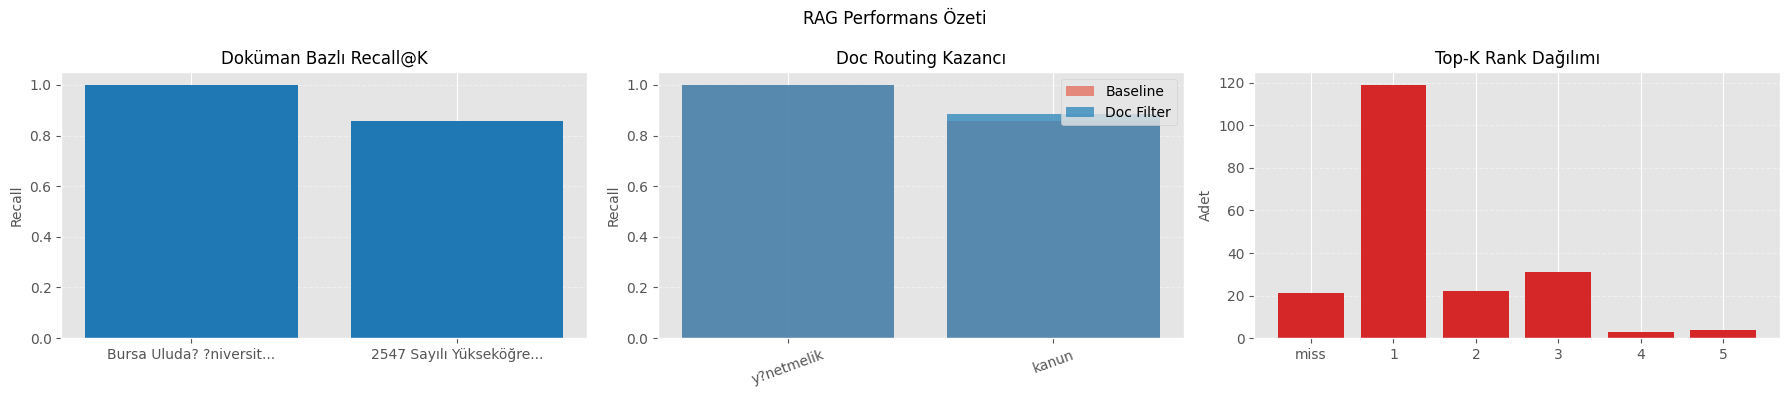

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))


doc_recall_plot = doc_recall.reset_index()
doc_names = doc_recall_plot['doc_name'].fillna('bilinmiyor').astype(str)
doc_names_display = doc_names.apply(lambda s: s if len(s) <= 25 else s[:22] + '...')
axes[0].bar(doc_names_display, doc_recall_plot['recall_at_k'].fillna(0.0), color='#1f77b4')
axes[0].set_title('Doküman Bazlı Recall@K')
axes[0].set_ylabel('Recall')
axes[0].tick_params(axis='x', labelrotation=0)


doc_filter_plot = doc_filter_summary.reset_index()
doc_types = doc_filter_plot['doc_type'].fillna('bilinmiyor').astype(str)
baseline_vals = doc_filter_plot['baseline_recall'].fillna(0.0)
doc_filter_vals = doc_filter_plot['doc_filter_recall'].fillna(0.0)
axes[1].bar(doc_types, baseline_vals, label='Baseline', alpha=0.6)
axes[1].bar(doc_types, doc_filter_vals, label='Doc Filter', alpha=0.8)
axes[1].set_title('Doc Routing Kazancı')
axes[1].set_ylabel('Recall')
axes[1].tick_params(axis='x', labelrotation=20)
axes[1].legend()


rank_counts = retrieval_details['relevant_rank'].fillna('miss').value_counts().reindex(['miss', 1, 2, 3, 4, 5], fill_value=0)
axes[2].bar(rank_counts.index.astype(str), rank_counts.values, color='#d62728')
axes[2].set_title('Top-K Rank Dağılımı')
axes[2].set_ylabel('Adet')
for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)


plt.suptitle('RAG Performans Özeti')
plt.show()